In [12]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("../data/processed/clean_nav_history.csv")

df['date'] = pd.to_datetime(df['date'])

print(df.info())
print(df.amfi_code)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[ns]
 2   nav        46000 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 1.1 MB
None
0        100016
1        100016
2        100016
3        100016
4        100016
          ...  
45995    149324
45996    149324
45997    149324
45998    149324
45999    149324
Name: amfi_code, Length: 46000, dtype: int64


In [14]:
selected_funds = [
    '119551',
    '120503',
    '118632',
    '119092',
    '120841',
    '125497',
    '101206',
    '100033',
    '103504',
    '145678'
]
df = df[df['amfi_code'].isin(selected_funds)]

In [19]:
pivot_df = df.pivot_table(
    index='date',
    columns='amfi_code',
    values='nav'
)

returns_df = pivot_df.pct_change()

correlation_matrix = returns_df.corr()

print(correlation_matrix)


print(df.columns.tolist())
print(df.head(2))

Empty DataFrame
Columns: []
Index: []
['amfi_code', 'date', 'nav']
Empty DataFrame
Columns: [amfi_code, date, nav]
Index: []


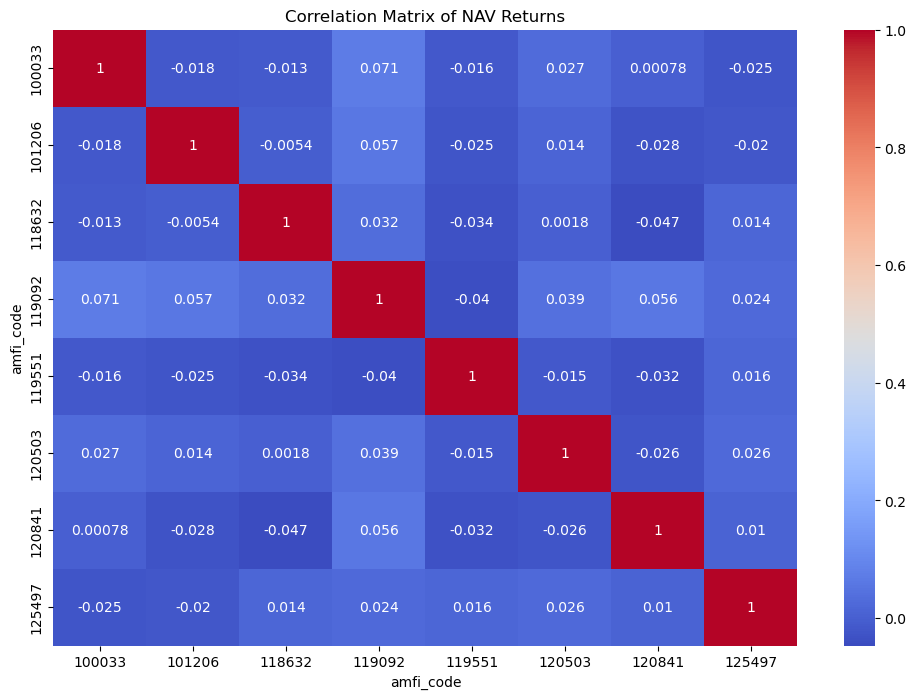

In [34]:
plt.figure(figsize=(12,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix of NAV Returns")

plt.show()